In [1]:
import sys
sys.path.insert(0, '/app')
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import warnings
import math
from numba import njit

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tabulate import tabulate
import seaborn as sns



from core.data_org import BUNDLE_DIR
from strat.strat_backtest import (
    compute_dual_momentum,
    get_current_allocation,
)
from strat.strat_analysis import (
    print_allocation_summary,
    print_metrics,
    compute_period_returns,
)
from strat.strat_visualise import (
    ETF_COLORS,
    plot_normalized_prices,
    create_allocation_gif,
    plot_pnl_histogram,
    plot_portfolio_value,
    plot_allocation_history,
    plot_cumulative_pnl,
    plot_monthly_returns_chart,
)
from backtest.dual_momentum_backtest import (
    generate_orders_from_allocations,
    compute_strategy_performance,
    save_backtest_diagnostics,
)
from core.data_org import (
    BUNDLE_DIR,
    get_normalised_instrument_dir,
    MktDataTFreq,
    ExchangeNAME,
    ProductType,
)
from core.enums import g_index_col
from norm.norm_utils import load_normalized_df
from features.feature_ta_utils import numba_roc_correct_min

etf_x_ext_list_clean = ['QQQ', 'SPY', 'SHV', 'TLT', 'GLD', 'VWO', 'XLB', 'XLE', 'GDX', 'XME', 'XLK', 'XLP', 'XLI', 'VNQ', 'XLV', 'DBC']
etf_x_list=etf_x_ext_list_clean
etf_x_list_product_type = [ProductType.ETF] * len(etf_x_list)


INPUT_FILE = Path("/data/bundle/etf_x_ext_list_features_bundle.parquet")
OUTPUT_DIR = Path("/data/work/dual_momentum_final/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input file: {INPUT_FILE}")
print(f"Output directory: {OUTPUT_DIR}")

/usr/local/lib/python3.12/site-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

Input file: /data/bundle/etf_x_ext_list_features_bundle.parquet
Output directory: /data/work/dual_momentum_final


## Configuration

Configure strategy and backtest parameters:

## Step 1: Load Data

Load the ETF features bundle:

In [3]:
df = pd.read_parquet(INPUT_FILE)
#df = df[48000:]
print(f"Loaded: {df.shape}")
print(f"Index: {df.index.name}, dtype: {df.index.dtype}")
print(f"Date range: {df.index.min()} to {df.index.max()}")



Loaded: (36874, 341)
Index: None, dtype: int64
Date range: 0 to 36873


In [4]:

periods = list(range(1000, 5000, 50))
print(f"Generating ROC for {len(periods)} periods: {periods[:10]}...{periods[-3:]}")

etfs = etf_x_list
mid_col = "F_mid_f32"
index_col = "i_minute_i"
# Build all new columns first, then concat once to avoid fragmentation
new_cols = {}
for etf in etfs:
    mid_price_col = f"{etf}_{mid_col}"
    
    for period in periods:
        col_name_true = f"{etf}_F_roctrue_{period}_{mid_col}_f16"
        if col_name_true not in df.columns:
            new_cols[col_name_true] = numba_roc_correct_min(df[mid_price_col].to_numpy(),df[index_col].to_numpy(), period*60)
            

# Add all columns at once
df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

print(f"DataFrame shape after ROC generation: {df.shape}")

# Update available lookbacks
roc_cols = [c for c in df.columns if "_roctrue_" in c]
available_lookbacks = sorted(set(int(c.split("_")[3]) for c in roc_cols))
print(f"Available ROC lookbacks: {len(available_lookbacks)} periods")
print(f"  First 10: {available_lookbacks[:10]}")
print(f"  Last 10: {available_lookbacks[-10:]}")



Generating ROC for 80 periods: [1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450]...[4850, 4900, 4950]
DataFrame shape after ROC generation: (36874, 1621)
Available ROC lookbacks: 80 periods
  First 10: [1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450]
  Last 10: [4500, 4550, 4600, 4650, 4700, 4750, 4800, 4850, 4900, 4950]


## Step 2: Run Dual Momentum Strategy

Compute allocations using the dual momentum strategy:

Strategy Parameters:
  lookback: 1500
  default_etf_idx: 2
  top_n: 2
  abs_momentum_threshold: 0.0
  feature_id: F_roc_1500_F_mid_f32_f16


<Axes: >

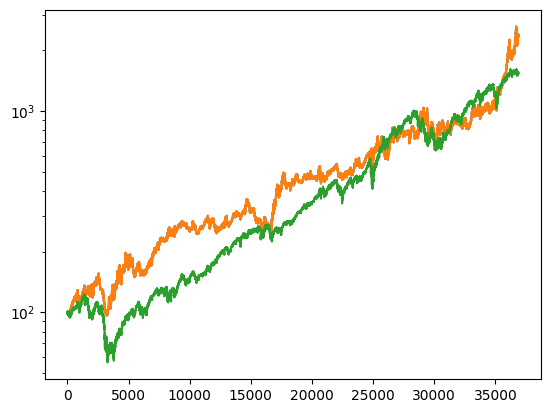

In [5]:



warnings.filterwarnings('ignore')



from backtest.backtest_basket_alloc_based import run_full_backtest

STRATEGY_PARAMS = {
    'lookback': 1500,  # ROC lookback period in bars
    'default_etf_idx': 2,  # TLT (safe haven)
    'top_n': 2,
    'abs_momentum_threshold': 0.00,
}
# Construct feature_id from lookback
STRATEGY_PARAMS['feature_id'] = f"F_roc_{STRATEGY_PARAMS['lookback']}_F_mid_f32_f16"

print("Strategy Parameters:")
for k, v in STRATEGY_PARAMS.items():
    print(f"  {k}: {v}")
# Construct feature_id from lookback
STRATEGY_PARAMS['feature_id_true'] = f"F_roctrue_{STRATEGY_PARAMS['lookback']}_F_mid_f32_f16"


etfs = etf_x_list
df_allocations_true = compute_dual_momentum(
    p_df=df,
    p_feature_id=STRATEGY_PARAMS['feature_id_true'],
    p_default_asset_idx=STRATEGY_PARAMS['default_etf_idx'],
    p_top_n=STRATEGY_PARAMS['top_n'],
    p_abs_momentum_threshold=STRATEGY_PARAMS['abs_momentum_threshold'],
    p_asset_list= etfs
)


p_df_true, orders_df = run_full_backtest(df_allocations_true,etfs)
p_df_true.port_value.plot(logy=True)

p_df_true.port_value.plot(logy=True)
p_df_true['QQQ_S_close_f32_norm']=p_df_true['QQQ_S_close_f32'].values/p_df_true['QQQ_S_close_f32'].values[0]*100
p_df_true['QQQ_S_close_f32_norm'].plot(logy=True)    

Calculating performance metrics...
Data range: 3697020 to 13757280 minutes since 2000-01-01
📊 PORTFOLIO PERFORMANCE SUMMARY

📅 PERIOD INFORMATION
--------------------------------------------------
Start Date:     2008-03-07 15:00
End Date:       2026-02-26 16:00
Total Period:   17.99 years

💰 PORTFOLIO VALUES
--------------------------------------------------
Start Value:    $135.69
End Value:      $2,397.56
Total Return:   +1666.89%
CAGR:           +17.31%

📊 RISK METRICS
--------------------------------------------------
Max Drawdown:   -38.45%
Max DD Peak:    2009-09-17
Max DD Valley:  2008-11-13
Annual Vol:     11.49%

📈 PERFORMANCE RATIOS
--------------------------------------------------
Sharpe Ratio:   0.15
Calmar Ratio:   0.45
Win Rate:       52.95%

📅 MONTHLY RETURNS MATRIX (%)
--------------------------------------------------
+------+-------+--------+-------+-------+--------+--------+--------+--------+--------+--------+-------+-------+
| year |  Jan  |  Feb   |  Mar  |  Apr 

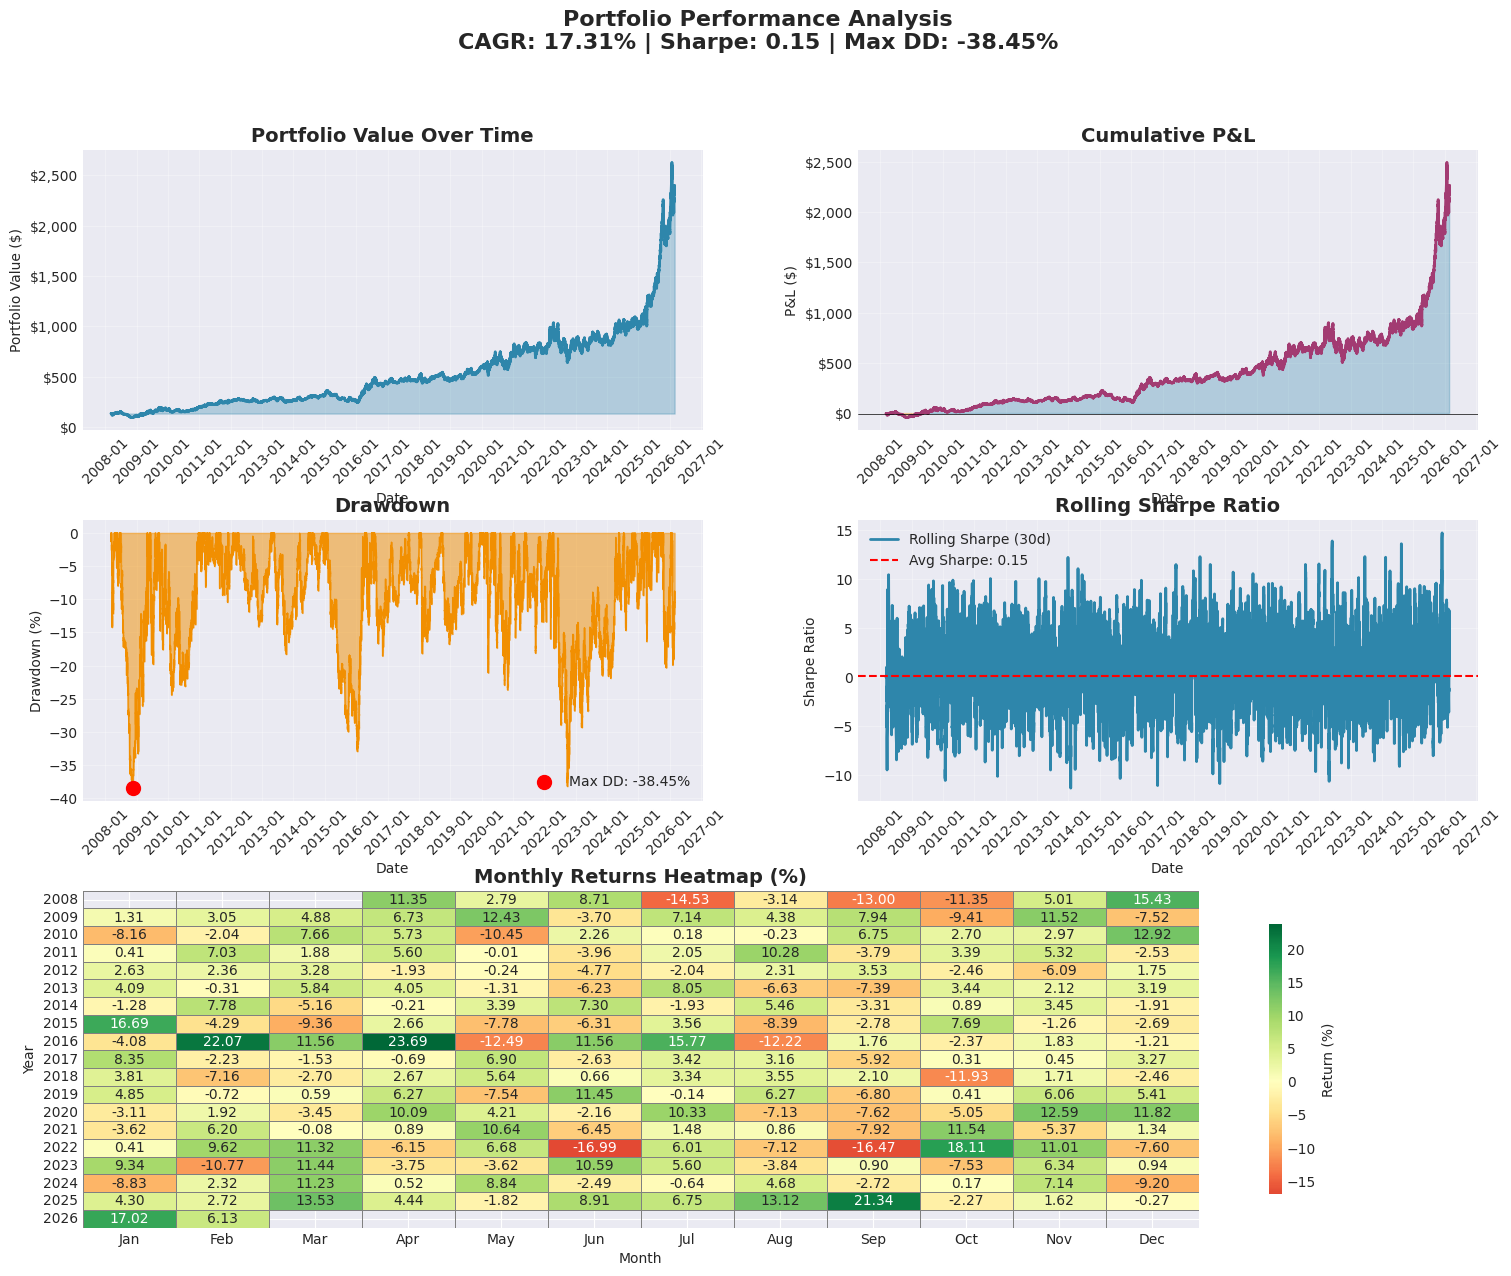


📌 Individual metrics:
   Years: 17.99
   Total Return: 1666.89%
   CAGR: 17.31%
   Sharpe: 0.15
   Calmar: 0.45
   Max DD: -38.45%


In [6]:

# Set style for better looking charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define month names globally so both functions can access it
MONTH_NAMES = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}


from backtest.backtest_alloc_based import calculate_performance_metrics, print_performance_summary, plot_performance_charts

# Usage
print("Calculating performance metrics...")
print(f"Data range: {p_df_true.iloc[0].i_minute_i} to {p_df_true.iloc[-1].i_minute_i} minutes since 2000-01-01")

metrics = calculate_performance_metrics(p_df_true[2000:])

# Print summary
print_performance_summary(metrics)

# Plot charts
print("\nGenerating performance charts...")
plot_performance_charts(metrics, save_fig=True, filename='portfolio_analysis.png')

# You can also access individual metrics
print(f"\n📌 Individual metrics:")
print(f"   Years: {metrics['years']}")
print(f"   Total Return: {metrics['total_return']}%")
print(f"   CAGR: {metrics['cagr']}%")
print(f"   Sharpe: {metrics['sharpe_ratio']}")
print(f"   Calmar: {metrics['calmar_ratio']}")
print(f"   Max DD: {metrics['max_drawdown']}%")

## Step 7: Generate Visualizations

Create and save all charts: